# `NescienceClassifier` demo

This notebook showcases the new `NescienceClassifier` class for the revised `mnplib` architecture.

The classifier implements **minimum-nescience model selection**:

```python
fit candidate classifier on (X, y)
extract explicit artifacts:
    subset, predictions, model_string
compute nescience
select the candidate with minimum nescience
```

The class does **not** use a train/test split or cross-validation. The theory evaluates the model with respect to the available effective representation `(X, y)`. Excessive complexity is penalized internally through the nescience components, especially `surfeit` and `surplus`.

This demo covers:

- default candidate search;
- custom candidate lists;
- result tables;
- component plots;
- explanations;
- class predictions;
- probability predictions;
- canonical model-string inspection;
- weight sensitivity;
- DataFrame feature-name preservation;
- multiclass classification;
- string-label preservation;
- strict unsupported-model behavior.


## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

from mnplib.classifier import NescienceClassifier
from mnplib.models import SerializationConfig

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Helper functions

These helpers are only for notebook display. They are not part of the library.


In [2]:
def plot_nescience(df, title):
    """Plot scalar nescience for candidate classifiers."""
    df.set_index("candidate")["nescience"].plot(kind="bar", figsize=(11, 4))
    plt.ylabel("Nescience")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_components(df, title):
    """Plot the four nescience components for candidate classifiers."""
    component_cols = ["deficiency", "surplus", "inaccuracy", "surfeit"]
    df.set_index("candidate")[component_cols].plot(kind="bar", figsize=(12, 5))
    plt.ylabel("Component value")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, labels, title):
    """Plot a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()


def print_section(title):
    """Print a visible separator."""
    print("\n" + title)
    print("=" * len(title))

## 3. Build a synthetic binary classification problem

The dataset has ten input features, but only four are informative. This is useful for seeing how different candidate classifiers trade off accuracy, feature use, and description length.


In [3]:
X, y = make_classification(
    n_samples=800,
    n_features=10,
    n_informative=4,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    class_sep=1.4,
    random_state=42,
)

feature_names = [f"x{i}" for i in range(X.shape[1])]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

X shape: (800, 10)
y shape: (800,)
Classes: [0 1]


## 4. Fit the default `NescienceClassifier`

The default candidate set currently includes:

- `LogisticRegression` with several values of `C`;
- `DecisionTreeClassifier` with several depth values.

All candidates are evaluated on the same representation `(X, y)`.


In [4]:
clf = NescienceClassifier(
    candidates="default",
    n_bins="auto",
    random_state=42,
    serialization_config=SerializationConfig(precision=4),
    verbose=1,
)

clf.fit(X, y)

logistic_C_0.1: nescience=0.621156, estimator_score=0.807500
logistic_C_1: nescience=0.620406, estimator_score=0.808750
logistic_C_10: nescience=0.619909, estimator_score=0.808750
tree_depth_2: nescience=0.649787, estimator_score=0.790000
tree_depth_3: nescience=0.605048, estimator_score=0.885000
tree_depth_5: nescience=0.624080, estimator_score=0.935000
tree_unrestricted: nescience=0.630308, estimator_score=1.000000


,candidates,'default'
,X_type,'numeric'
,aggregation,'euclidean'
,weights,None
,n_bins,'auto'
,threshold_fraction,0.01
,surplus_penalty,1.0
,zlib_level,9
,zlib_overhead,6
,serialization_config,Serialization...indent=' ')
,random_state,42


## 5. Selected classifier and main diagnostics

In [5]:
print("Best candidate:", clf.best_candidate_name_)
print("Selected estimator:", type(clf.get_model()).__name__)
print("Best nescience:", clf.nescience_score())
print("Native classifier score on full data:", clf.score(X, y))
print("Accuracy:", accuracy_score(y, clf.predict(X)))
print("Classes:", clf.classes_)

print("\nComponents:")
for name, value in clf.components().items():
    print(f"{name:>10}: {value:.6f}")

Best candidate: tree_depth_3
Selected estimator: DecisionTreeClassifier
Best nescience: 0.6050480395823152
Native classifier score on full data: 0.885
Accuracy: 0.885
Classes: [0 1]

Components:
deficiency: 0.005000
   surplus: 0.895690
inaccuracy: 0.507375
   surfeit: 0.636095


## 6. Candidate comparison table

`results_dataframe()` gives a compact table with the selected classifier first because rows are sorted by ascending nescience.


In [6]:
results = clf.results_dataframe()
results

,candidate,model_type,nescience,estimator_score,n_features_in_use,description_length,deficiency,surplus,inaccuracy,surfeit
0,tree_depth_3,DecisionTreeClassifier,0.605048,0.88500,4,676,0.005000,0.895690,0.507375,0.636095
1,logistic_C_10,LogisticRegression,0.619909,0.80875,10,592,0.000000,0.896311,0.703889,0.488176
2,logistic_C_1,LogisticRegression,0.620406,0.80875,10,591,0.000000,0.896311,0.703889,0.490694
3,logistic_C_0.1,LogisticRegression,0.621156,0.80750,10,591,0.000000,0.896311,0.706530,0.490694
4,tree_depth_5,DecisionTreeClassifier,0.624080,0.93500,8,2127,0.000000,0.896311,0.324299,0.805830
5,tree_unrestricted,DecisionTreeClassifier,0.630308,1.00000,10,7036,0.000000,0.896311,0.000000,0.886441
6,tree_depth_2,DecisionTreeClassifier,0.649787,0.79000,2,361,0.419764,0.918043,0.678954,0.457064


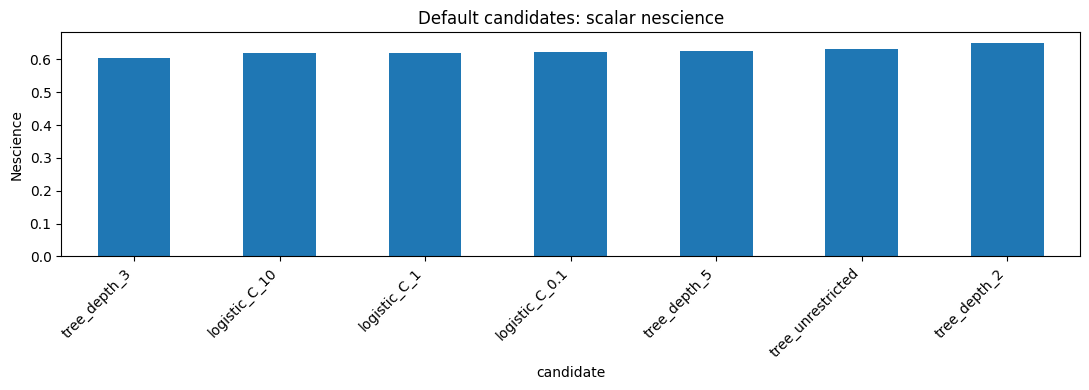

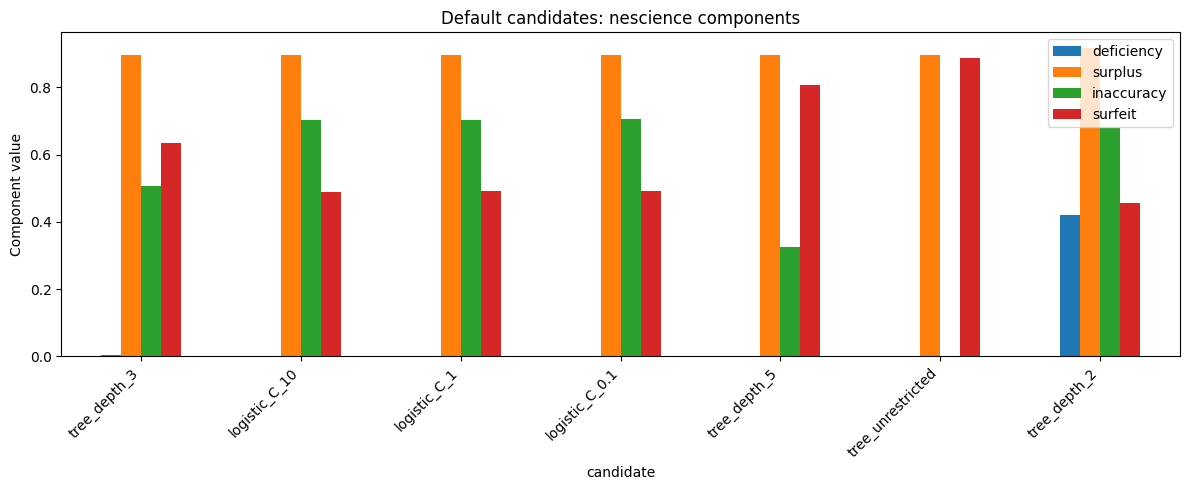

In [7]:
plot_nescience(results, "Default candidates: scalar nescience")
plot_components(results, "Default candidates: nescience components")

## 7. Native predictive score versus nescience

The native estimator score for classifiers is usually accuracy, while nescience is a different objective. A classifier may have high accuracy but still have higher nescience because its description is unnecessarily complex or because it uses irrelevant information.


In [8]:
comparison = results[
    [
        "candidate",
        "model_type",
        "estimator_score",
        "nescience",
        "inaccuracy",
        "surfeit",
        "n_features_in_use",
        "description_length",
    ]
].copy()

comparison.sort_values("estimator_score", ascending=False)

,candidate,model_type,estimator_score,nescience,inaccuracy,surfeit,n_features_in_use,description_length
5,tree_unrestricted,DecisionTreeClassifier,1.00000,0.630308,0.000000,0.886441,10,7036
4,tree_depth_5,DecisionTreeClassifier,0.93500,0.624080,0.324299,0.805830,8,2127
0,tree_depth_3,DecisionTreeClassifier,0.88500,0.605048,0.507375,0.636095,4,676
2,logistic_C_1,LogisticRegression,0.80875,0.620406,0.703889,0.490694,10,591
1,logistic_C_10,LogisticRegression,0.80875,0.619909,0.703889,0.488176,10,592
3,logistic_C_0.1,LogisticRegression,0.80750,0.621156,0.706530,0.490694,10,591
6,tree_depth_2,DecisionTreeClassifier,0.79000,0.649787,0.678954,0.457064,2,361


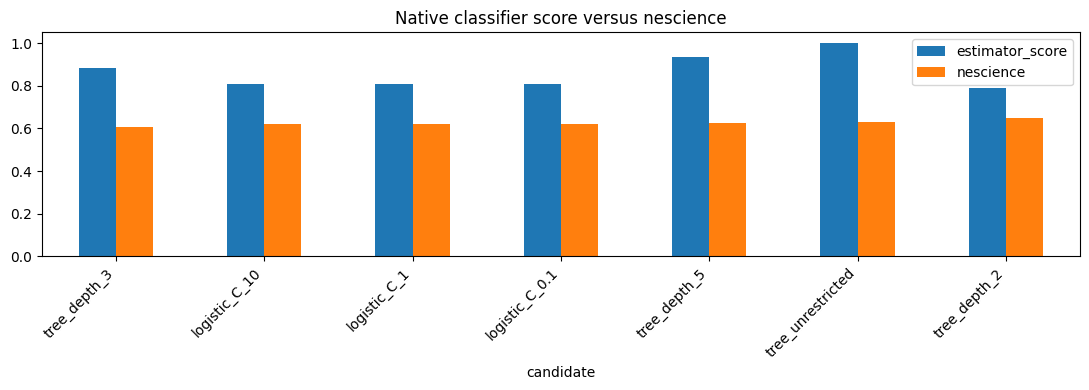

In [9]:
comparison.set_index("candidate")[["estimator_score", "nescience"]].plot(
    kind="bar",
    figsize=(11, 4),
)
plt.title("Native classifier score versus nescience")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Predictions, probabilities, and confusion matrix

Predictions shape: (800,)
Probabilities shape: (800, 2)
First 5 predictions: [0 1 1 1 0]
First 5 probability rows:
[[0.86263736 0.13736264]
 [0.01321586 0.98678414]
 [0.2        0.8       ]
 [0.31764706 0.68235294]
 [0.98285714 0.01714286]]


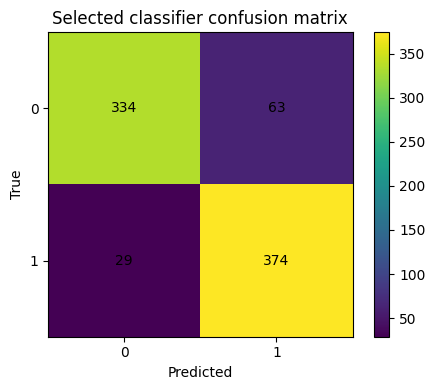

In [10]:
predictions = clf.predict(X)
probabilities = clf.predict_proba(X)

print("Predictions shape:", predictions.shape)
print("Probabilities shape:", probabilities.shape)
print("First 5 predictions:", predictions[:5])
print("First 5 probability rows:")
print(probabilities[:5])

plot_confusion(y, predictions, labels=clf.classes_, title="Selected classifier confusion matrix")

## 9. Explanation of the selected classifier

`explain()` delegates to the fitted `Nescience` object and adds the selected candidate name plus adapter metadata.


In [11]:
explanation = clf.explain()

print("Candidate:", explanation["candidate_name"])
print("Model type:", explanation["model_type"])
print("Dominant component:", explanation["dominant_component"])
print("Profile:", explanation["profile"])
print("Recommendation:", explanation["recommendation"])

print("\nModel metadata:")
for key, value in explanation["model_metadata"].items():
    print(f"{key}: {value}")

Candidate: tree_depth_3
Model type: DecisionTreeClassifier
Dominant component: surplus
Profile: over_fed_model
Recommendation: Dominant source of nescience: surplus (0.8957). Reduce target-irrelevant input information: apply feature selection, increase the surplus penalty, remove noisy variables, or simplify the representation used by the model.

Model metadata:
n_nodes: 15
n_leaves: 8
max_depth: 3
task: classification
schema: canonical_nescience_model_v1
support_level: stable
serializer: decision_tree
n_features_in: 10
n_features_in_use: 4
selected_feature_names: ['x1', 'x3', 'x5', 'x8']


## 10. Inspect the canonical model string

The selected classifier is serialized into the canonical model-description schema used by the new scikit-learn adapter layer.


In [12]:
model_string = clf.model_string()

print(model_string[:2500])
print("\nDescription length in bytes:", len(model_string.encode("utf-8")))

SCHEMA canonical_nescience_model_v1
MODEL DecisionTreeClassifier
TASK classification
INPUTS x1, x3, x5, x8
PARAMETERS
    n_nodes = 15
    n_leaves = 8
    max_depth = 3
RULE
    if x3 <= -0.1151:
        if x5 <= -0.1393:
            if x1 <= -3.1490:
                return 1
            else:
                return 0
        else:
            if x1 <= 0.0340:
                return 1
            else:
                return 0
    else:
        if x3 <= 0.3825:
            if x8 <= -1.2411:
                return 0
            else:
                return 1
        else:
            if x1 <= 2.9180:
                return 1
            else:
                return 0


Description length in bytes: 676


## 11. Custom candidate set

For demos or controlled experiments, it is often better to pass an explicit candidate list.


In [13]:
custom_candidates = [
    ("logistic_C_0.1", LogisticRegression(C=0.1, max_iter=1000, random_state=42)),
    ("logistic_C_1", LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
    ("logistic_C_10", LogisticRegression(C=10.0, max_iter=1000, random_state=42)),
    ("tree_depth_2", DecisionTreeClassifier(max_depth=2, random_state=42)),
    ("tree_depth_4", DecisionTreeClassifier(max_depth=4, random_state=42)),
    ("tree_unrestricted", DecisionTreeClassifier(random_state=42)),
]

custom_clf = NescienceClassifier(
    candidates=custom_candidates,
    n_bins="auto",
    random_state=42,
    serialization_config=SerializationConfig(precision=4),
)

custom_clf.fit(X, y)

custom_results = custom_clf.results_dataframe()
custom_results

,candidate,model_type,nescience,estimator_score,n_features_in_use,description_length,deficiency,surplus,inaccuracy,surfeit
0,tree_depth_4,DecisionTreeClassifier,0.619558,0.90875,7,1219,0.000000,0.896311,0.432360,0.738310
1,logistic_C_10,LogisticRegression,0.619909,0.80875,10,592,0.000000,0.896311,0.703889,0.488176
2,logistic_C_1,LogisticRegression,0.620406,0.80875,10,591,0.000000,0.896311,0.703889,0.490694
3,logistic_C_0.1,LogisticRegression,0.621156,0.80750,10,591,0.000000,0.896311,0.706530,0.490694
4,tree_unrestricted,DecisionTreeClassifier,0.630308,1.00000,10,7036,0.000000,0.896311,0.000000,0.886441
5,tree_depth_2,DecisionTreeClassifier,0.649787,0.79000,2,361,0.419764,0.918043,0.678954,0.457064


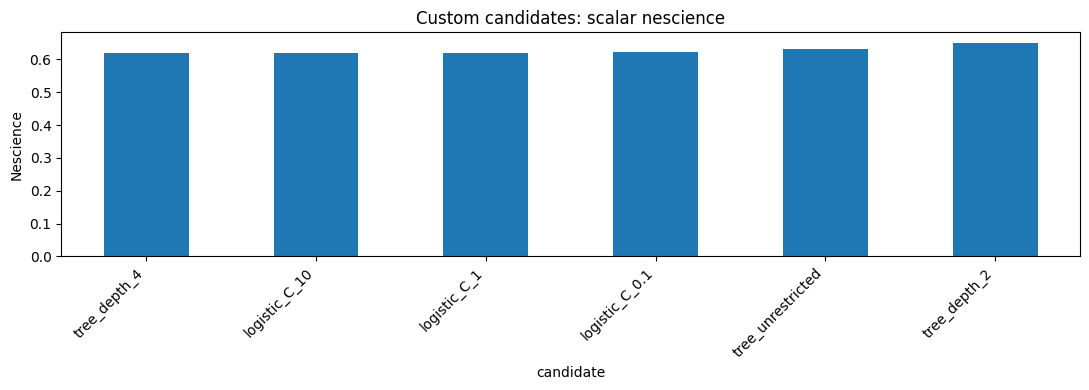

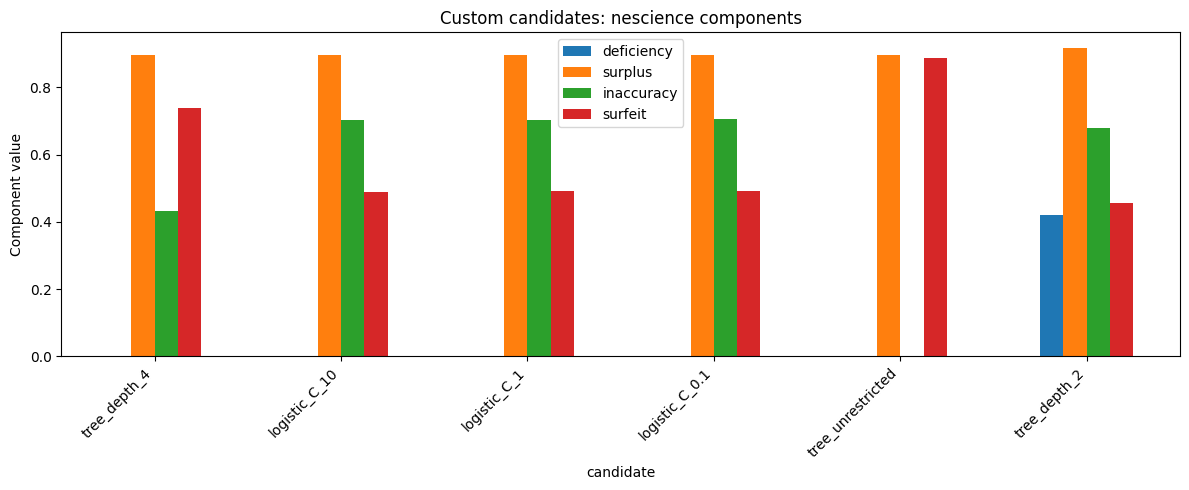

In [14]:
plot_nescience(custom_results, "Custom candidates: scalar nescience")
plot_components(custom_results, "Custom candidates: nescience components")

## 12. Weight sensitivity

The classifier selected by minimum nescience may change if you give more importance to some components.

Here we compare three objectives:

- balanced;
- prediction-focused;
- simplicity-focused.


In [15]:
weight_settings = {
    "balanced": None,
    "prediction_focused": {
        "deficiency": 1.0,
        "surplus": 1.0,
        "inaccuracy": 3.0,
        "surfeit": 1.0,
    },
    "simplicity_focused": {
        "deficiency": 1.0,
        "surplus": 2.0,
        "inaccuracy": 1.0,
        "surfeit": 3.0,
    },
}

weight_rows = []

for setting_name, weights in weight_settings.items():
    selector = NescienceClassifier(
        candidates=custom_candidates,
        aggregation="euclidean",
        weights=weights,
        n_bins="auto",
        random_state=42,
        serialization_config=SerializationConfig(precision=4),
    )
    selector.fit(X, y)

    weight_rows.append(
        {
            "setting": setting_name,
            "best_candidate": selector.best_candidate_name_,
            "best_model_type": type(selector.get_model()).__name__,
            "best_nescience": selector.best_nescience_,
            **selector.best_components_,
        }
    )

weight_results = pd.DataFrame(weight_rows)
weight_results

,setting,best_candidate,best_model_type,best_nescience,deficiency,surplus,inaccuracy,surfeit
0,balanced,tree_depth_4,DecisionTreeClassifier,0.619558,0.0,0.896311,0.432360,0.738310
1,prediction_focused,tree_unrestricted,DecisionTreeClassifier,0.514644,0.0,0.896311,0.000000,0.886441
2,simplicity_focused,logistic_C_10,LogisticRegression,0.634390,0.0,0.896311,0.703889,0.488176


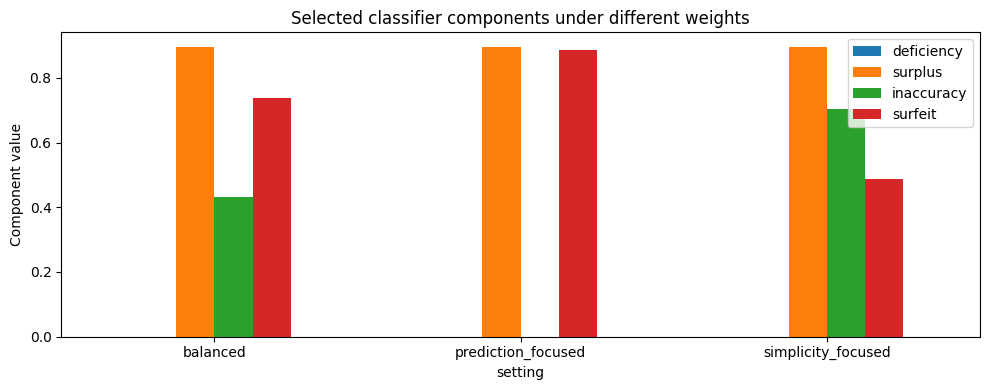

In [16]:
weight_results.set_index("setting")[
    ["deficiency", "surplus", "inaccuracy", "surfeit"]
].plot(kind="bar", figsize=(10, 4))

plt.ylabel("Component value")
plt.title("Selected classifier components under different weights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. DataFrame feature names

If `X` is a pandas DataFrame, the canonical model strings preserve column names.


In [17]:
X_df = pd.DataFrame(X, columns=[f"feature_{j}" for j in range(X.shape[1])])

df_clf = NescienceClassifier(
    candidates=[
        ("logistic", LogisticRegression(max_iter=1000, random_state=42)),
        ("tree_depth_3", DecisionTreeClassifier(max_depth=3, random_state=42)),
    ],
    n_bins="auto",
    random_state=42,
    serialization_config=SerializationConfig(precision=4),
)

df_clf.fit(X_df, y)

print("Feature names stored in the classifier:")
print(list(df_clf.feature_names_in_))

print("\nCanonical model string excerpt:")
print(df_clf.model_string()[:1500])

Feature names stored in the classifier:
['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']

Canonical model string excerpt:
SCHEMA canonical_nescience_model_v1
MODEL DecisionTreeClassifier
TASK classification
INPUTS feature_1, feature_3, feature_5, feature_8
PARAMETERS
    n_nodes = 15
    n_leaves = 8
    max_depth = 3
RULE
    if feature_3 <= -0.1151:
        if feature_5 <= -0.1393:
            if feature_1 <= -3.1490:
                return 1
            else:
                return 0
        else:
            if feature_1 <= 0.0340:
                return 1
            else:
                return 0
    else:
        if feature_3 <= 0.3825:
            if feature_8 <= -1.2411:
                return 0
            else:
                return 1
        else:
            if feature_1 <= 2.9180:
                return 1
            else:
                return 0



## 14. Multiclass classification

The class also supports multiclass problems as long as the underlying model serializer supports the selected estimator.


In [18]:
Xm, ym = make_classification(
    n_samples=900,
    n_features=12,
    n_informative=5,
    n_redundant=0,
    n_repeated=0,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.3,
    random_state=123,
)

multiclass_clf = NescienceClassifier(
    candidates=[
        ("logistic", LogisticRegression(max_iter=1000, random_state=42)),
        ("tree_depth_3", DecisionTreeClassifier(max_depth=3, random_state=42)),
        ("tree_depth_5", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ],
    n_bins="auto",
    random_state=42,
    serialization_config=SerializationConfig(precision=4),
)

multiclass_clf.fit(Xm, ym)

print("Best candidate:", multiclass_clf.best_candidate_name_)
print("Classes:", multiclass_clf.classes_)
print("Accuracy:", multiclass_clf.score(Xm, ym))
print("Nescience:", multiclass_clf.nescience_score())

multiclass_clf.results_dataframe()

Best candidate: logistic
Classes: [0 1 2]
Accuracy: 0.9311111111111111
Nescience: 0.5440013070443648


,candidate,model_type,nescience,estimator_score,n_features_in_use,description_length,deficiency,surplus,inaccuracy,surfeit
0,logistic,LogisticRegression,0.544001,0.931111,12,1364,0.000000,0.838500,0.251968,0.645894
1,tree_depth_3,DecisionTreeClassifier,0.555110,0.897778,4,675,0.002804,0.837407,0.351605,0.638519
2,tree_depth_5,DecisionTreeClassifier,0.592349,0.936667,8,2129,0.000000,0.838500,0.225329,0.806012


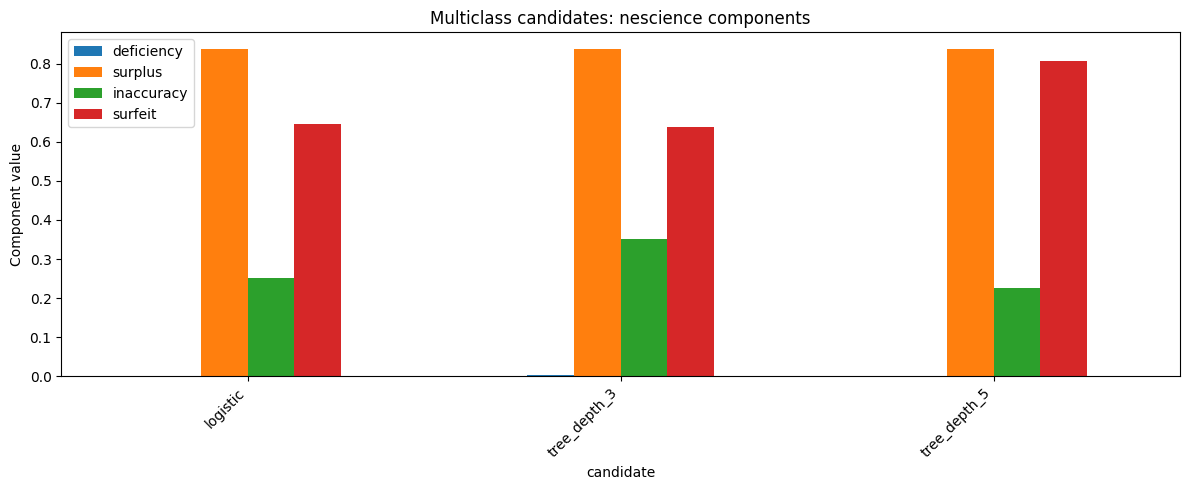

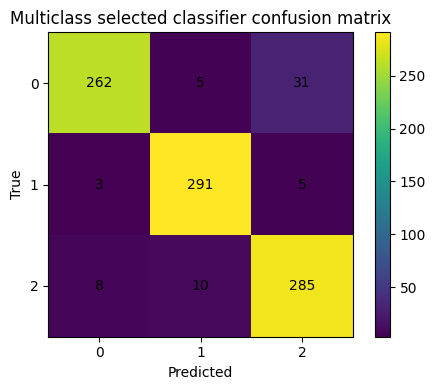

In [19]:
plot_components(
    multiclass_clf.results_dataframe(),
    "Multiclass candidates: nescience components",
)

plot_confusion(
    ym,
    multiclass_clf.predict(Xm),
    labels=multiclass_clf.classes_,
    title="Multiclass selected classifier confusion matrix",
)

## 15. String-label preservation

The classifier preserves original labels. This is useful when target classes are semantic labels rather than integers.


In [20]:
string_labels = np.array([f"class_{label}" for label in y])

string_clf = NescienceClassifier(
    candidates=[
        ("tree_depth_3", DecisionTreeClassifier(max_depth=3, random_state=42)),
        ("logistic", LogisticRegression(max_iter=1000, random_state=42)),
    ],
    n_bins="auto",
    random_state=42,
    serialization_config=SerializationConfig(precision=4),
)

string_clf.fit(X, string_labels)

print("Stored classes:", string_clf.classes_)
print("First 10 predictions:")
print(string_clf.predict(X[:10]))

print("\nCanonical string excerpt:")
print(string_clf.model_string()[:1500])

Stored classes: ['class_0' 'class_1']
First 10 predictions:
['class_0' 'class_1' 'class_1' 'class_1' 'class_0' 'class_0' 'class_1'
 'class_1' 'class_1' 'class_0']

Canonical string excerpt:
SCHEMA canonical_nescience_model_v1
MODEL DecisionTreeClassifier
TASK classification
INPUTS x1, x3, x5, x8
PARAMETERS
    n_nodes = 15
    n_leaves = 8
    max_depth = 3
RULE
    if x3 <= -0.1151:
        if x5 <= -0.1393:
            if x1 <= -3.1490:
                return 'class_1'
            else:
                return 'class_0'
        else:
            if x1 <= 0.0340:
                return 'class_1'
            else:
                return 'class_0'
    else:
        if x3 <= 0.3825:
            if x8 <= -1.2411:
                return 'class_0'
            else:
                return 'class_1'
        else:
            if x1 <= 2.9180:
                return 'class_1'
            else:
                return 'class_0'



## 16. Strict unsupported-model behavior

Unsupported models should fail explicitly. This avoids silently using an incorrect feature subset or an incomparable model string.


In [21]:
try:
    unsupported = NescienceClassifier(
        candidates=[("dummy", DummyClassifier(strategy="most_frequent"))],
        n_bins="auto",
    )
    unsupported.fit(X, y)
except NotImplementedError as exc:
    print(type(exc).__name__)
    print(exc)

NotImplementedError
No scikit-learn serializer registered for DummyClassifier.


## 17. Summary

The new `NescienceClassifier` is a small model-selection orchestrator:

```python
NescienceClassifier
    -> fits candidate classifiers on (X, y)
    -> extracts canonical artifacts with mnplib.models
    -> computes nescience with Nescience
    -> selects the candidate with minimum nescience
```

Its most useful outputs are:

```python
clf.best_candidate_name_
clf.best_nescience_
clf.components()
clf.explain()
clf.results_dataframe()
clf.model_string()
clf.predict(X)
clf.predict_proba(X)
```

This keeps the model-selection logic separate from the metric classes and from the model serializers.
